In [5]:
import torch


def _h_to_transposed(H: torch.Tensor, n: int, p: int) -> torch.Tensor:
    """Unpack Hilbert integer(s) into Skilling's transposed representation."""
    X = torch.zeros(*H.shape, n, dtype=torch.int64, device=H.device)
    for i in range(p):
        for j in range(n):
            bit = (H >> (n * p - 1 - (i * n + j))) & 1
            X[..., j] |= bit << (p - 1 - i)
    return X


def _transposed_to_h(X: torch.Tensor, n: int, p: int) -> torch.Tensor:
    """Pack Skilling's transposed representation into Hilbert integer(s)."""
    H = torch.zeros(X.shape[0], dtype=torch.int64, device=X.device)
    for i in range(p):
        for j in range(n):
            bit = (X[:, j] >> (p - 1 - i)) & 1
            H |= bit << (n * p - 1 - (i * n + j))
    return H


def _inverse_hilbert_transform(X: torch.Tensor, n: int, p: int) -> torch.Tensor:
    """Skilling inverse transform: transposed Hilbert form → coordinates."""
    X = X.clone()
    M = 1 << (p - 1)

    # Gray decode by prefix scan
    t = X[:, n - 1] >> 1
    for i in range(n - 1, 0, -1):
        X[:, i] ^= X[:, i - 1]
    X[:, 0] ^= t

    # Undo excess work
    Q = 2
    while Q != M << 1:
        P = Q - 1
        for i in range(n - 1, -1, -1):
            hi  = (X[:, i] & Q) != 0
            swp = (X[:, 0] ^ X[:, i]) & P
            X[:, 0] = torch.where(hi, X[:, 0] ^ P, X[:, 0] ^ swp)
            X[:, i] = torch.where(hi, X[:, i],      X[:, i] ^ swp)
        Q <<= 1

    return X


def _forward_hilbert_transform(X: torch.Tensor, n: int, p: int) -> torch.Tensor:
    """Skilling forward transform: coordinates → transposed Hilbert form."""
    X = X.clone()
    M = 1 << (p - 1)

    # Inverse undo
    Q = M
    while Q > 1:
        P = Q - 1
        for i in range(n):
            hi  = (X[:, i] & Q) != 0
            swp = (X[:, 0] ^ X[:, i]) & P
            X[:, 0] = torch.where(hi, X[:, 0] ^ P, X[:, 0] ^ swp)
            X[:, i] = torch.where(hi, X[:, i],      X[:, i] ^ swp)
        Q >>= 1

    # Gray encode
    for i in range(1, n):
        X[:, i] ^= X[:, i - 1]
    t = torch.zeros(X.shape[0], dtype=torch.int64, device=X.device)
    Q = M
    while Q > 1:
        t = torch.where((X[:, n - 1] & Q) != 0, t ^ (Q - 1), t)
        Q >>= 1
    for i in range(n):
        X[:, i] ^= t

    return X


def decode(hilbert_indices, num_dims: int, num_bits: int,
           device: str = "cpu") -> torch.Tensor:
    """Decode Hilbert indices → coordinates.

    Args:
        hilbert_indices : array-like or 1-D int64 Tensor.
        num_dims        : number of spatial dimensions.
        num_bits        : bits per axis  (grid size = 2**num_bits per axis).
        device          : torch device (used only when input is not a Tensor).
    Returns:
        int64 Tensor of shape (N, num_dims).
    """
    if not isinstance(hilbert_indices, torch.Tensor):
        hilbert_indices = torch.tensor(hilbert_indices, dtype=torch.int64, device=device)
    X = _h_to_transposed(hilbert_indices.to(torch.int64), num_dims, num_bits)
    return _inverse_hilbert_transform(X, num_dims, num_bits)


def encode(coords, num_dims: int, num_bits: int,
           device: str = "cpu") -> torch.Tensor:
    """Encode coordinates → Hilbert indices.

    Args:
        coords   : array-like or Tensor of shape (N, num_dims), integer coords.
        num_dims : number of spatial dimensions.
        num_bits : bits per axis.
        device   : torch device (used only when input is not a Tensor).
    Returns:
        int64 Tensor of shape (N,).
    """
    if not isinstance(coords, torch.Tensor):
        coords = torch.tensor(coords, dtype=torch.int64, device=device)
    X = _forward_hilbert_transform(coords.to(torch.int64), num_dims, num_bits)
    return _transposed_to_h(X, num_dims, num_bits)


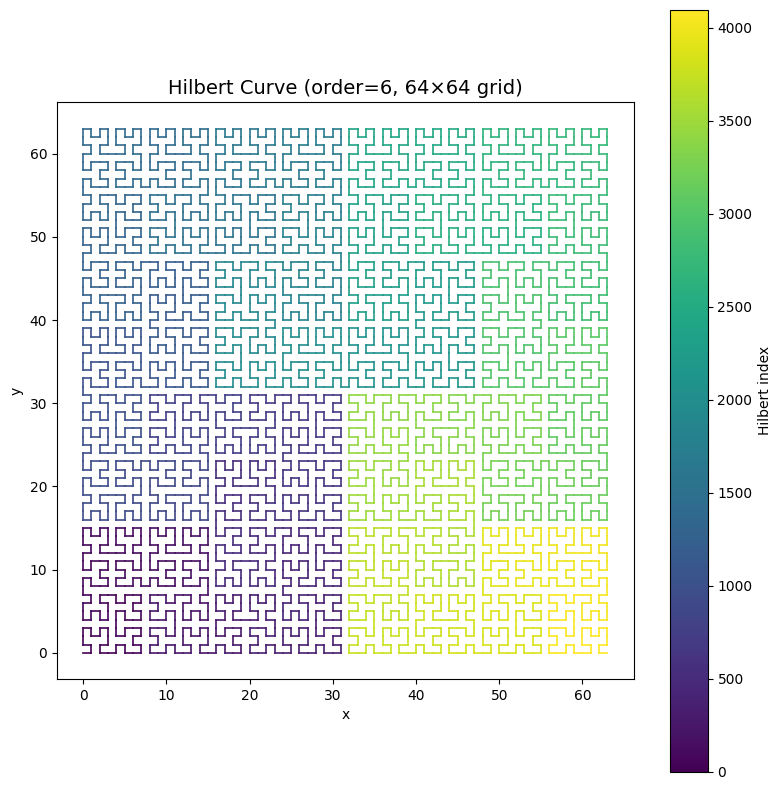

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Verify against the original `hilbert` package ────────────────────────

indices = np.array([0, 1, 2, 3, 5, 7, 8], dtype=np.uint64)
our_locs = decode(indices, 2, 7).numpy()       # torch implementation
our_H = encode(our_locs, 2, 7).numpy()

# ── Plot the Hilbert curve using the torch implementation ─────────────────
def plot_hilbert_curve(order: int = 4, figsize=(8, 8)):
    """Plot a 2-D Hilbert curve of the given order."""
    n_points = 2 ** (2 * order)
    indices  = torch.arange(n_points, dtype=torch.int64)
    locs     = decode(indices, 2, order)          # (n_points, 2) torch Tensor
    x, y     = locs[:, 0].numpy(), locs[:, 1].numpy()

    fig, ax = plt.subplots(figsize=figsize)
    colors  = cm.viridis(np.linspace(0, 1, n_points - 1))
    for i in range(n_points - 1):
        ax.plot([x[i], x[i + 1]], [y[i], y[i + 1]], color=colors[i], linewidth=1.2)

    sm = cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, n_points))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Hilbert index")

    ax.set_title(f"Hilbert Curve (order={order}, {2**order}×{2**order} grid)", fontsize=14)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()

plot_hilbert_curve(order=6)


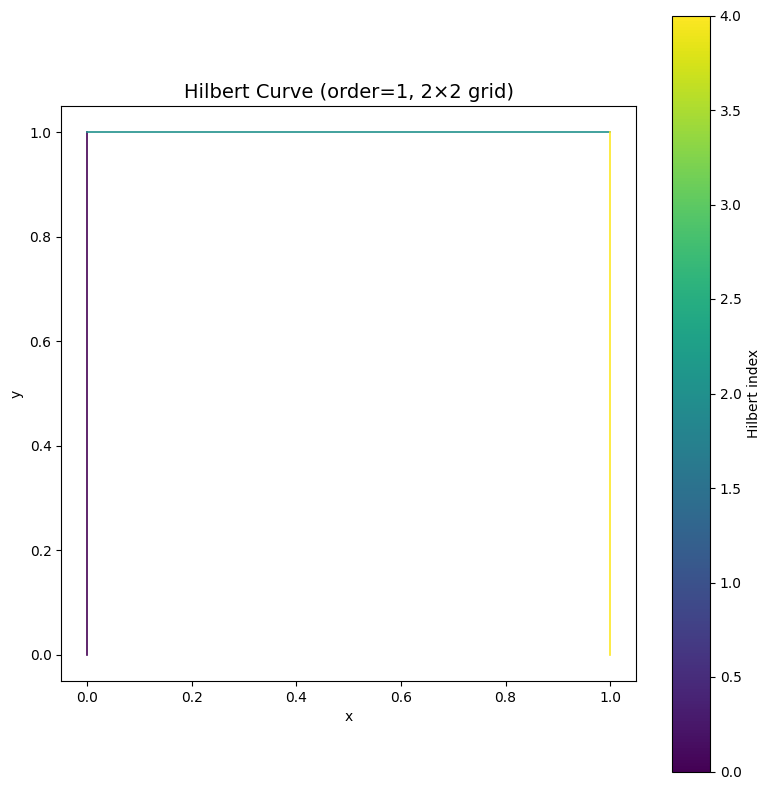

In [7]:
plot_hilbert_curve(order=1)

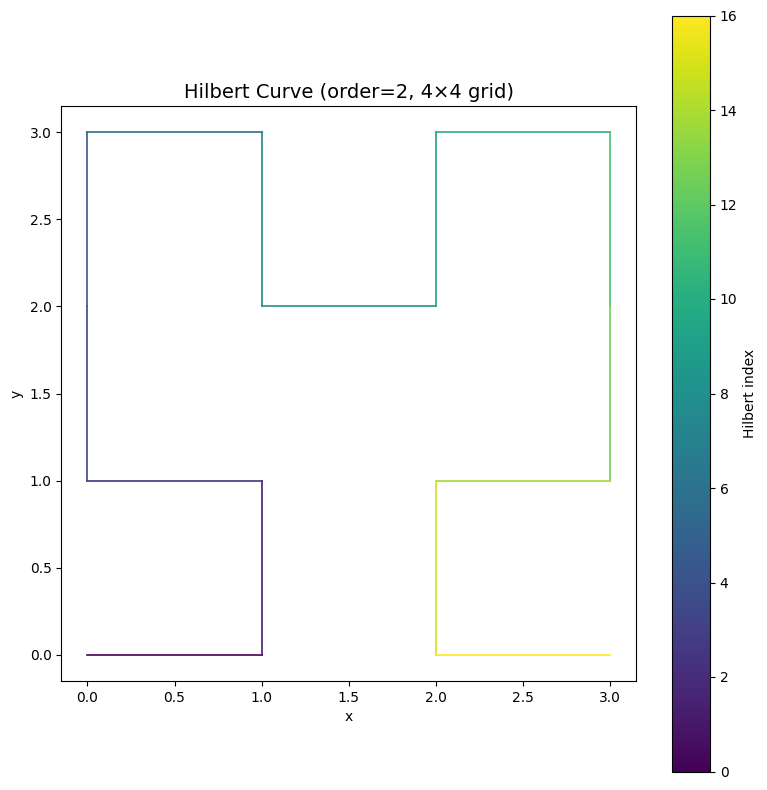

In [8]:
plot_hilbert_curve(order=2)


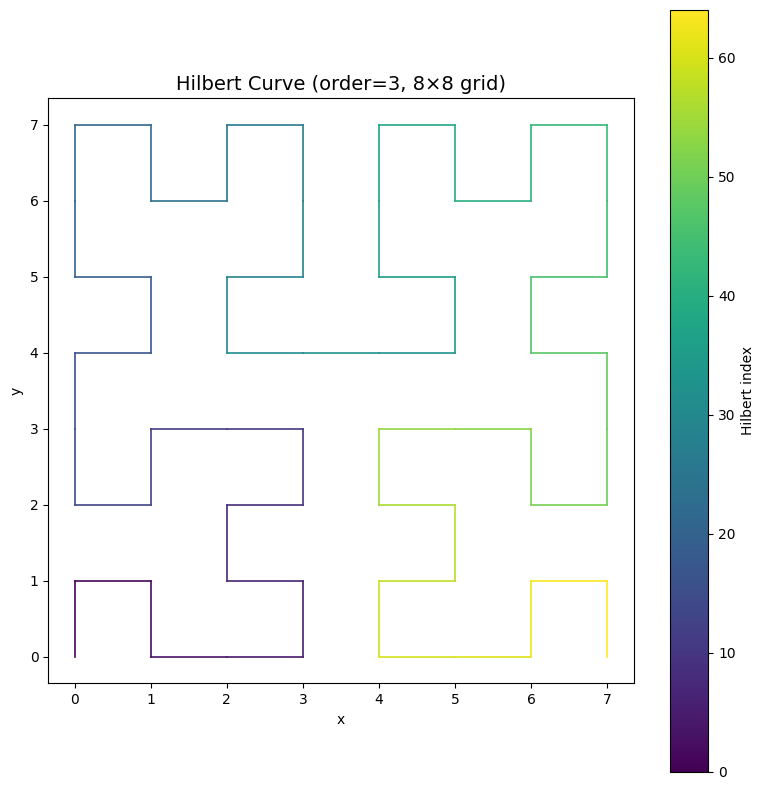

In [9]:
plot_hilbert_curve(order=3)


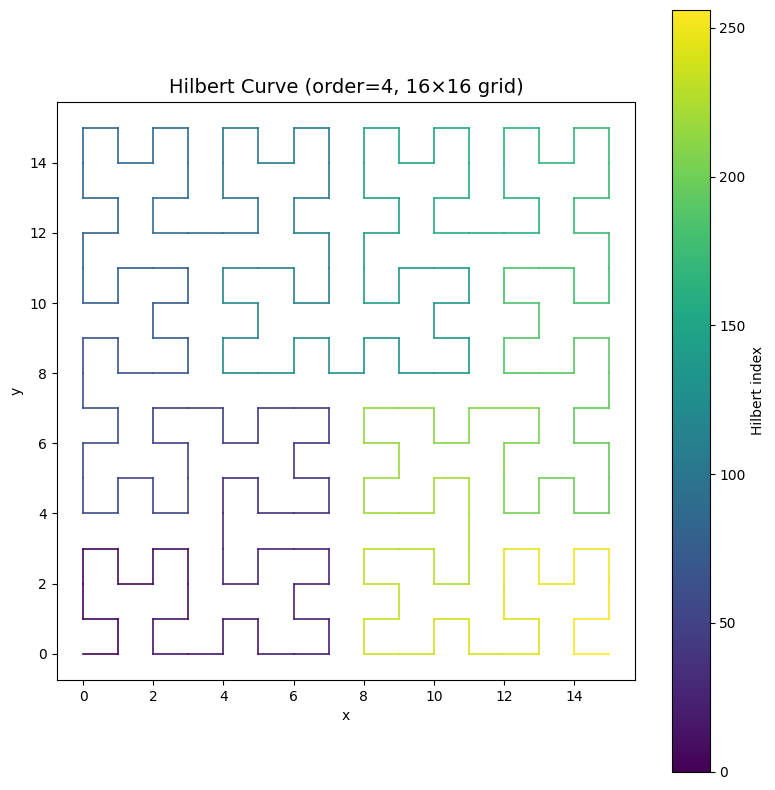

In [10]:
plot_hilbert_curve(order=4)


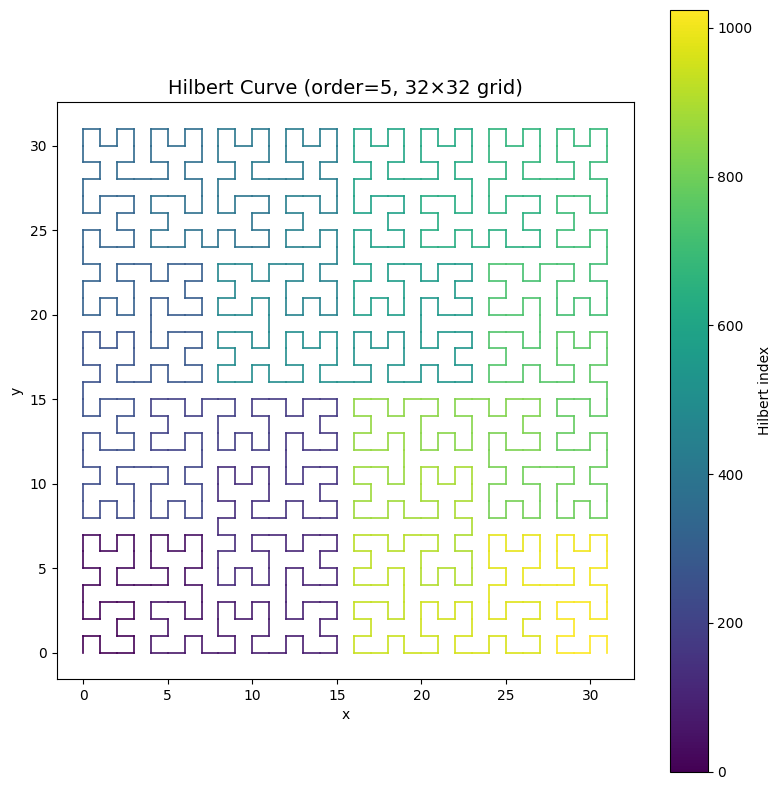

In [11]:
plot_hilbert_curve(order=5)


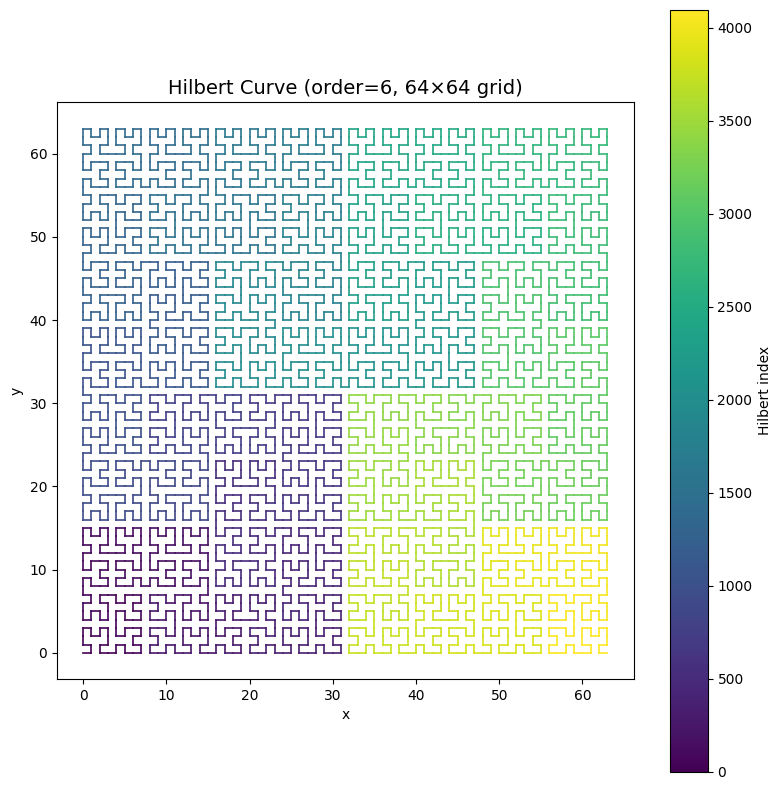

In [12]:
plot_hilbert_curve(order=6)